# Import statements

In [125]:
# import statements

# astropy
from astropy.io import fits
from astropy.wcs import WCS
import astropy.units as u
from astropy.table import QTable, Table

# matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# general / misc
import numpy as np
import pandas as pd
import sys
from reproject import reproject_interp

# not an import statement but need this somewhere
u.add_enabled_units([u.def_unit('MJY/SR', u.MJy / u.sr)])

# Fetching galaxy properties from PHANGS table

In [175]:
# read in the PHANGS sample table -- note that public version with basic info doesn't have inclination, which we need
props_tab=Table.read('/Users/adignan/Documents/GitHub/co_to_h2/phangs_sample_table_v1p6.csv',header_start=184)

# pick our sample ahead of time
targets=['ngc0628', 'ngc1097', 'ngc3351', 'ngc3521', 'ngc3621', 'ngc3627',
         'ngc4254', 'ngc4321', 'ngc4536', 'ngc4569', 'ngc4579', 'ngc4631',
         'ngc4826', 'ngc5194', 'ngc5457', 'ngc7793']

props_filt=props_tab[np.isin(props_tab['name'], targets)]
# props_filt

# Required files

In [324]:
# CO moment zero map and corresponding uncertainty map
# WISE 1, 3, and 4 maps 
co='/Users/adignan/research/phangs/ngc0628/alma/ngc0628_12m+7m+tp_co21_2.566192048arcsec_broad_mom0.fits'
co_err='/Users/adignan/research/phangs/ngc0628/alma/ngc0628_12m+7m+tp_co21_2.566192048arcsec_broad_emom0.fits'

w1_7p5='/Users/adignan/research/phangs/wise_all/ngc0628_w1_gauss7p5.fits'
w1_15='/Users/adignan/research/phangs/wise_all/ngc0628_w1_gauss15.fits'
w3_7p5='/Users/adignan/research/phangs/wise_all/ngc0628_w3_gauss7p5.fits'
w4_15='/Users/adignan/research/phangs/wise_all/ngc0628_w4_gauss15.fits'

# comparisons
massmap='/Users/adignan/Documents/GitHub/co_to_h2/NGC0628.ica2.massmap.sm_Msunpc2.fits'

# Defining other functions

In [321]:
def plotmap(data_in, clabel=None, norm=False, cmap='viridis', title=None):
    plt.figure()
    if norm:
        plt.imshow(data_in, norm=LogNorm(), cmap=cmap)
    else:
        plt.imshow(data_in, cmap=cmap)
    if title:
        plt.title(title)
    if clabel:
        plt.colorbar(label=clabel)
    if clabel==None:
        plt.colorbar()

# Defining class and methods

In [340]:
class Map:
    '''This class sets up a FITS file for calculations.'''

    def __init__(self, path=None, data=None, header=None, unit=None):
        '''Extracts the data and header from the FITS file.'''
        # extract data array and header from FITS file
        if path is not None:
            data, header = fits.getdata(path, ext=0, header=True)
            self.hdr = header

        # split into attributes 
        self.data = data
        self.hdr = header

        if unit:
            self.unit = unit
        elif header is not None and header['BUNIT'] is not None:
            unit=u.Unit(header['BUNIT'])
            self.unit = unit
        if unit is None:
            self.unit = u.dimensionless_unscaled

    def reproject(self, template_file, plot=False, title=None):
        '''Reprojects the FITS file data onto the WCS and size of the input
        template FITS file and returns the reprojected data array as 
        a Quantity based on the original FITS file data units.'''
        # create an instance of the input template FITS file
        template=Map(template_file)

        # remove all axes with length=1 so array is 2D
        data_in = np.squeeze(self.data)

        # get WCS for file to be reprojected and template 
        wcs_in=WCS(self.hdr)
        wcs_out=WCS(template.hdr)

        # get size for reprojection from header of template
        ny=template.hdr['NAXIS2']
        nx=template.hdr['NAXIS1']

        # reproject!
        data_out, footprint = reproject_interp((data_in, wcs_in), wcs_out,
                                               shape_out=(ny, nx))
        # replace any invalid values in reprojected image with NaN
        data_out[footprint <= 0] = np.nan

        if plot == True:
            plotmap(data_out, norm=True, clabel=str(self.unit), title=title)

        return Map(data=data_out, header=self.hdr)

    def add_col(self, t, name, length=None):
        '''Adds a column called 'name' to a table t.
        Flattens the data and adds as a Quantity.'''
        t[name] = np.array(self.data).reshape(-1) * self.unit
        if length:
            t[name] = np.full(length, self.data) * self.unit
        return t[name]
    
    def calc_gamma(self, method='', gal_sfr = None, gal_Mstar = None,
               I_w4 = None, I_w3 = None, I_w1 = None):
        # All colors are logarithmic ratios of specific luminosity in Jy, i.e., Lν and not νLν (Leroy+19).
        if method == 'GSWLC':
            # maybe put in a "if gal_sfr and gal_Mstar blank then print need that stuff"
            a = -10.9
            b = -0.21
            c = -9.5
            gal_sfr = gal_sfr * u.M_sun / u.yr
            gal_Mstar = gal_Mstar * u.M_sun
            q=np.log10(gal_sfr.value/gal_Mstar.value)
            
        if method == 'W3/W1':
            a = 0.1
            b = -0.46
            c = 0.75
            q=np.log10(I_w3.value/I_w1.value)

        if method == 'W4/W1':
            a = 0.0
            b = -0.4
            c = 0.75
            q=np.log10(I_w4/I_w1).value

        gamma = np.where(q < a, 0.5,
                np.where(q > c, 0.2,
                0.5+b*(q - a)))

        return Map(data=gamma, unit=u.M_sun / u.L_sun)
    
    def calc_sig_star(self, gamma, I_w1, i, plot=False, method=None):
        sig_star = 330 * (gamma/0.5) * I_w1/(u.MJy/u.sr) * np.cos(np.deg2rad(i))

        if plot == True:
            plotmap(sig_star.data, norm=True, clabel=r'M$_\odot$/pc$^{2}$', cmap='inferno', 
                    title=rf'$\Sigma_{{\star}}: \mathrm{{{method}}}$')

        return Map(data=sig_star, unit=u.M_sun/(u.pc)**2)

In [341]:
ngc0628_sfr=props_filt['props_sfr'][0]
ngc0628_mstar=props_filt['props_mstar'][0]
ngc0628_inc=props_filt['orient_incl'][0]
print(ngc0628_sfr,ngc0628_mstar)

1.7524408 21940600000.0


INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                 [astropy.wcs.wcs]
-0.07169851852201015

/var/folders/lh/hfr5b6k95hq4fknmrpwk9t280000gp/T/ipykernel_93467/682301014.py:76: RuntimeWarning: invalid value encountered in log10
  q=np.log10(I_w3.value/I_w1.value)
/Users/adignan/miniconda3/lib/python3.12/site-packages/astropy/units/quantity.py:648: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


reproj_w1_7p5,reproj_w3_7p5,GSWLC gamma,GSWLC sigma SFR,W3/W1 gamma,W3/W1 sigma SFR,W4/W1 gamma,W4/W1 sigma SFR
MJY/SR,MJY/SR,solMass / solLum,solMass / pc2,solMass / solLum,solMass / pc2,solMass / solLum,solMass / pc2
float64,float64,float64,float64,float64,float64,float64,float64
0.014625113007629496,-0.06391425659342381,0.33149708025585223,3.1612742668655853,nan,nan,0.2,1.9103074590844091
0.014529883253856082,-0.06668496199598128,0.33149708025585223,3.1406899903620946,nan,nan,0.2,1.9114907610570087
0.014434653513140522,-0.06945566610495564,0.33149708025585223,3.1201057166811093,nan,nan,0.2,1.9126740633079202
0.01433942378541201,-0.07222636892033756,0.33149708025585223,3.0995214458073246,nan,nan,0.2,1.9138573658334004
0.014244194070828633,-0.07499707044365254,0.33149708025585223,3.078937177774911,nan,nan,0.2,1.9150406686419017
0.014148964369166243,-0.07776777067409885,0.33149708025585223,3.058352912535418,nan,nan,0.2,1.9162239717216405
0.014053734680454687,-0.08053846961302744,0.33149708025585223,3.0377686500952983,nan,nan,0.2,1.91740727507517
0.01395850500486898,-0.0833091672623083,0.33149708025585223,3.01718439049238,nan,nan,0.2,1.9185905787132087


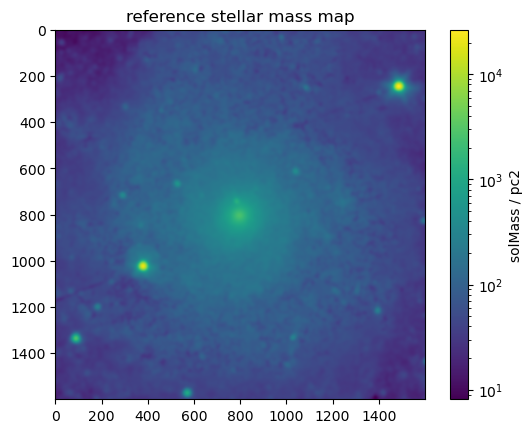

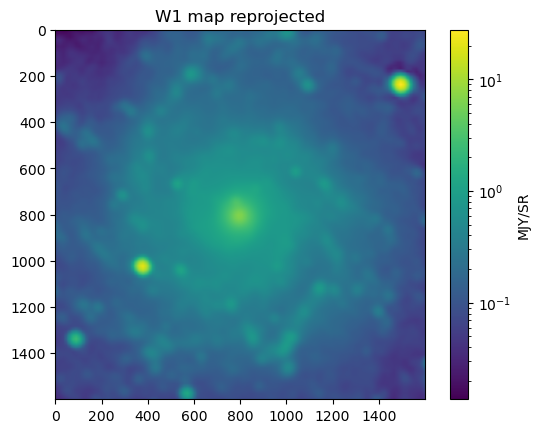

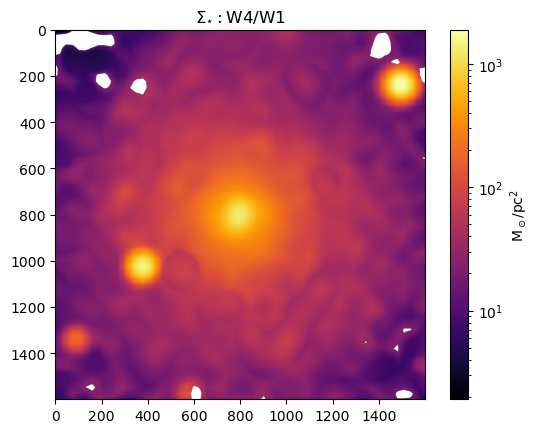

In [342]:
w1_7p5_map=Map(w1_7p5)
w1_15_map=Map(w1_15)
w3_7p5_map=Map(w3_7p5)
w4_15_map=Map(w4_15)

co_map=Map(co)

mass_map=Map(massmap)
mass_map_reproj=mass_map.reproject(template_file=co,plot=True,title='reference stellar mass map')

print(np.min(w1_7p5_map.data))

w1_7p5_reproj=w1_7p5_map.reproject(template_file=co,plot=True,title='W1 map reprojected')
w1_15_reproj=w1_15_map.reproject(template_file=co)
w3_7p5_reproj=w3_7p5_map.reproject(template_file=co)
w4_15_reproj=w4_15_map.reproject(template_file=co)

# plotmap(w1_7p5_map.data)
# plotmap(w1_reproj.data)
# plotmap(co_map.data)

tab=QTable() # empty

w1_7p5_reproj.add_col(t=tab, name='reproj_w1_7p5')
w3_7p5_reproj.add_col(t=tab, name='reproj_w3_7p5')

# GSWLC 
gam_gswlc=w1_7p5_reproj.calc_gamma(method='GSWLC',gal_sfr=ngc0628_sfr,gal_Mstar=ngc0628_mstar) # should be scalar
gam_gswlc.add_col(t=tab, name='GSWLC gamma',length=len(tab))

sig_gswlc=w1_7p5_reproj.calc_sig_star(gamma=gam_gswlc.data, I_w1=w1_7p5_reproj.data*w1_7p5_reproj.unit, i=ngc0628_inc)
sig_gswlc.add_col(t=tab, name='GSWLC sigma SFR')

# W3/W1
gam_w3w1=w1_7p5_reproj.calc_gamma(method='W3/W1', I_w3=w3_7p5_reproj.data*w3_7p5_reproj.unit, 
                                                    I_w1=w1_7p5_reproj.data*w1_7p5_reproj.unit) 
gam_w3w1.add_col(t=tab, name='W3/W1 gamma')

sig_w3w1=w1_7p5_reproj.calc_sig_star(gamma=gam_w3w1.data, I_w1=w1_7p5_reproj.data*w1_7p5_reproj.unit, i=ngc0628_inc)
sig_w3w1.add_col(t=tab, name='W3/W1 sigma SFR')

# W4/W1
gam_w4w1=w1_15_reproj.calc_gamma(method='W4/W1', I_w4=w4_15_reproj.data*w1_15_reproj.unit, 
                                                    I_w1=w1_15_reproj.data*w1_15_reproj.unit) 
gam_w4w1.add_col(t=tab, name='W4/W1 gamma')

sig_w4w1=w1_15_reproj.calc_sig_star(gamma=gam_w4w1.data, I_w1=w1_15_reproj.data*w1_15_reproj.unit, i=ngc0628_inc, 
                                    plot=True, method='W4/W1')
sig_w4w1.add_col(t=tab, name='W4/W1 sigma SFR')

tab


# Read in required FITS files

# Reproject WISE maps onto CO grid